# Task 2. Interpolation of the internal gaps

Task 2 asks us to fill in the embedded missing blocks inside each series and quantify the uncertainty of the estimates. From Task 1, the most important lessons are:

- raw prices are highly persistent and should not be modeled directly,
- log-returns are much closer to stationary than price levels,
- most series show volatility clustering, so uncertainty should depend on local return variability.

Based on that, the interpolation below works on the log-price scale and uses a local Gaussian bridge between the observed prices immediately before and after each internal gap.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

repo_root = Path.cwd()
if not (repo_root / "config").exists():
    repo_root = repo_root.parent
sys.path.append(str(repo_root))

from config.plot_config import plot_config
from Subtasks.series_analysis import PriceAnalysis

plot_config()


## 1. Load the cleaned data and identify the interpolation targets

We only interpolate the internal missing blocks. The shared trailing 200-day gap belongs to Task 3 and must not be touched here.


In [2]:
analysis = PriceAnalysis.from_csv("spiff_data-2.csv").clean()
prices = analysis.prices
gap_table = analysis.gap_table()
internal_gaps = gap_table[gap_table["gap_type"] == "internal"].copy()
trailing_gaps = gap_table[gap_table["gap_type"] == "trailing"].copy()

print("Internal gaps:")
display(internal_gaps)
print("\nTrailing gaps reserved for Task 3:")
display(trailing_gaps)


Internal gaps:


,series,start,end,length,gap_type
0,guitars,399,448,50,internal
2,gurkor,199,248,50,internal
4,slingshots,599,648,50,internal
6,stocks,799,848,50,internal
8,sugar,999,1048,50,internal
10,tranquillity,1399,1448,50,internal
12,water,1199,1248,50,internal



Trailing gaps reserved for Task 3:


,series,start,end,length,gap_type
1,guitars,5257,5456,200,trailing
3,gurkor,5257,5456,200,trailing
5,slingshots,5257,5456,200,trailing
7,stocks,5257,5456,200,trailing
9,sugar,5257,5456,200,trailing
11,tranquillity,5257,5456,200,trailing
13,water,5257,5456,200,trailing


## 2. Interpolation model

Let $Y_t = \, \log X_t$ be the log-price. Suppose an internal gap has length $m$, and the observed log-prices immediately before and after the gap are $Y_0$ and $Y_{m+1}$. Under a Gaussian random-walk model, the conditional expectation inside the gap is the Brownian-bridge mean

$$
\mathbb{E}[Y_h \mid Y_0, Y_{m+1}] = Y_0 + \frac{h}{m+1}(Y_{m+1} - Y_0), \qquad h = 1, \dots, m.
$$

This gives a smooth interpolation on the log-price scale. The conditional variance is

$$
\operatorname{Var}(Y_h \mid Y_0, Y_{m+1}) = \sigma^2 \frac{h(m+1-h)}{m+1},
$$

where $\sigma^2$ is the one-step return variance. We estimate $\sigma^2$ locally from observed log-returns in a window before and after the gap so that the interval width reflects the volatility regime around the missing block.


In [3]:
log_returns = analysis.log_returns
variance_window = 60
z_value = 1.96
validation_gap_length = int(internal_gaps["length"].mode().iloc[0])
max_validation_windows = 12
context_window = 40


def bridge_interpolate_window(series, return_series, start, end, variance_window=60, z_value=1.96):
    gap_length = end - start + 1
    left_log_price = np.log(series.loc[start - 1])
    right_log_price = np.log(series.loc[end + 1])
    steps = np.arange(1, gap_length + 1)
    bridge_mean = left_log_price + steps / (gap_length + 1) * (right_log_price - left_log_price)

    local_returns = pd.concat(
        [
            return_series.loc[: start - 1].dropna().tail(variance_window),
            return_series.loc[end + 2 :].dropna().head(variance_window),
        ]
    )
    local_variance = local_returns.var(ddof=1)
    if pd.isna(local_variance) or local_variance <= 0:
        local_variance = return_series.dropna().var(ddof=1)

    bridge_variance = local_variance * steps * (gap_length + 1 - steps) / (gap_length + 1)
    bridge_std = np.sqrt(bridge_variance)
    gap_index = pd.Index(range(start, end + 1), name=series.index.name)

    return pd.DataFrame(
        {
            "estimate": np.exp(bridge_mean),
            "lower_95": np.exp(bridge_mean - z_value * bridge_std),
            "upper_95": np.exp(bridge_mean + z_value * bridge_std),
            "log_price_mean": bridge_mean,
            "log_price_std": bridge_std,
            "local_return_variance": local_variance,
        },
        index=gap_index,
    )


def candidate_gap_starts(series, gap_length):
    starts = []
    first_start = int(series.index.min()) + 1
    last_start = int(series.index.max()) - gap_length

    for start in range(first_start, last_start + 1):
        end = start + gap_length - 1
        if series.loc[start - 1 : end + 1].notna().all():
            starts.append(start)

    return starts


def evaluate_bridge_interpolator(prices, log_returns, gap_length, variance_window=60, max_windows=12):
    rows = []

    for column in prices.columns:
        series = prices[column]
        return_series = log_returns[column]
        starts = candidate_gap_starts(series, gap_length)

        if len(starts) > max_windows:
            selected = np.linspace(0, len(starts) - 1, max_windows, dtype=int)
            starts = [starts[i] for i in selected]

        for start in starts:
            end = start + gap_length - 1
            interpolation = bridge_interpolate_window(series, return_series, start, end, variance_window=variance_window)
            true_prices = series.loc[start:end]
            true_log_prices = np.log(true_prices)

            rows.append(
                {
                    "series": column,
                    "start": start,
                    "end": end,
                    "price_rmse": float(np.sqrt(np.mean((interpolation["estimate"].to_numpy() - true_prices.to_numpy()) ** 2))),
                    "log_price_rmse": float(np.sqrt(np.mean((interpolation["log_price_mean"].to_numpy() - true_log_prices.to_numpy()) ** 2))),
                    "coverage_95": float(
                        np.mean(
                            (true_prices.to_numpy() >= interpolation["lower_95"].to_numpy())
                            & (true_prices.to_numpy() <= interpolation["upper_95"].to_numpy())
                        )
                    ),
                    "avg_interval_width": float(np.mean(interpolation["upper_95"] - interpolation["lower_95"])),
                }
            )

    return pd.DataFrame(rows)


## 3. Backtest the interpolation rule with pseudo-gaps

To evaluate expected performance without leaking information from the true missing block, we create artificial 50-day gaps in fully observed stretches of each series, interpolate them using only the observations outside the hidden block, and compare the reconstruction with the known truth.


In [4]:
backtest_results = evaluate_bridge_interpolator(
    prices,
    log_returns,
    gap_length=validation_gap_length,
    variance_window=variance_window,
    max_windows=max_validation_windows,
)

backtest_summary = backtest_results.groupby("series")[
    ["price_rmse", "log_price_rmse", "coverage_95", "avg_interval_width"]
].mean().sort_values("log_price_rmse")

overall_backtest = backtest_results[["price_rmse", "log_price_rmse", "coverage_95", "avg_interval_width"]].mean().to_frame("overall")

display(backtest_summary)
display(overall_backtest)


,price_rmse,log_price_rmse,coverage_95,avg_interval_width
series,,,,
water,0.048399,0.008093,0.986667,0.220625
gurkor,0.091510,0.009724,0.960000,0.360730
tranquillity,0.465713,0.038496,0.913333,1.703849
guitars,0.242648,0.038803,0.926667,0.892111
slingshots,0.141933,0.038860,0.941667,0.534807
stocks,0.263891,0.039477,0.948333,1.081616
sugar,0.114601,0.042355,0.940000,0.413014


,overall
price_rmse,0.195528
log_price_rmse,0.030830
coverage_95,0.945238
avg_interval_width,0.743822


The coverage column is especially useful for uncertainty assessment. If the 95% intervals are statistically reasonable, the empirical coverage from the pseudo-gaps should be in the neighborhood of 95%, even if it is not exact for every asset.


## 4. Interpolate the true internal gaps

For the real missing blocks, using both endpoints of the gap is legitimate because the task is interpolation rather than forecasting. We therefore apply the same bridge model to each asset's internal gap and keep the 95% interval for every imputed point.


In [5]:
interpolated_prices = prices.copy()
lower_95_prices = prices.copy()
upper_95_prices = prices.copy()
interpolated_gap_frames = []
interpolation_summary_rows = []

for row in internal_gaps.itertuples(index=False):
    gap_interpolation = analysis.interpolate_internal_gap(row.series, variance_window=variance_window, z_value=z_value)
    interpolated_gap_frames.append(gap_interpolation.reset_index().rename(columns={prices.index.name: "day"}))

    interpolated_prices.loc[gap_interpolation.index, row.series] = gap_interpolation["estimate"].to_numpy()
    lower_95_prices.loc[gap_interpolation.index, row.series] = gap_interpolation["lower_95"].to_numpy()
    upper_95_prices.loc[gap_interpolation.index, row.series] = gap_interpolation["upper_95"].to_numpy()

    midpoint_day = int(gap_interpolation.index[len(gap_interpolation) // 2])
    interpolation_summary_rows.append(
        {
            "series": row.series,
            "gap_start": row.start,
            "gap_end": row.end,
            "gap_length": row.length,
            "midpoint_day": midpoint_day,
            "midpoint_estimate": float(gap_interpolation.loc[midpoint_day, "estimate"]),
            "avg_interval_width": float(np.mean(gap_interpolation["upper_95"] - gap_interpolation["lower_95"])),
            "local_return_variance": float(gap_interpolation["local_return_variance"].iloc[0]),
        }
    )

interpolated_gap_values = pd.concat(interpolated_gap_frames, ignore_index=True).set_index(["series", "day"])
interpolation_summary = pd.DataFrame(interpolation_summary_rows).set_index("series").sort_index()

display(interpolation_summary)
display(interpolated_gap_values.head(15))


,gap_start,gap_end,gap_length,midpoint_day,midpoint_estimate,avg_interval_width,local_return_variance
series,,,,,,,
guitars,399,448,50,424,3.286032,0.384765,0.000109
gurkor,199,248,50,224,6.586692,0.281681,0.000015
slingshots,599,648,50,624,2.468263,0.174919,0.000040
stocks,799,848,50,824,12.463394,2.137973,0.000234
sugar,999,1048,50,1024,3.559343,0.462921,0.000135
tranquillity,1399,1448,50,1424,8.624282,0.824972,0.000073
water,1199,1248,50,1224,4.755851,0.134574,0.000006


estimate  lower_95  upper_95  log_price_mean  log_price_std  \
series  day                                                                
guitars 399  3.423211  3.354456  3.493376        1.230579       0.010352   
        400  3.417616  3.321903  3.516086        1.228943       0.014492   
        401  3.412029  3.296545  3.531560        1.227307       0.017568   
        402  3.406452  3.275035  3.543143        1.225671       0.020073   
        403  3.400884  3.256064  3.552144        1.224035       0.022202   
        404  3.395325  3.238955  3.559243        1.222399       0.024055   
        405  3.389775  3.223302  3.564845        1.220763       0.025692   
        406  3.384234  3.208837  3.569217        1.219128       0.027152   
        407  3.378702  3.195376  3.572546        1.217492       0.028463   
        408  3.373179  3.182781  3.574967        1.215856       0.029643   
        409  3.367665  3.170950  3.576584        1.214220       0.030708   
        410  3.362160  3.159804  3.577477        1.212584       0.031670   
        411  3.356665  3.149277  3.577709        1.210948       0.032538   
        412  3.351178  3.139320  3.577333        1.209312       0.033319   
        413  3.345700  3.129890  3.576390        1.207676       0.034019   

             local_return_variance  
series  day                         
guitars 399               0.000109  
        400               0.000109  
        401               0.000109  
        402               0.000109  
        403               0.000109  
        404               0.000109  
        405               0.000109  
        406               0.000109  
        407               0.000109  
        408               0.000109  
        409               0.000109  
        410               0.000109  
        411               0.000109  
        412               0.000109  
        413               0.000109

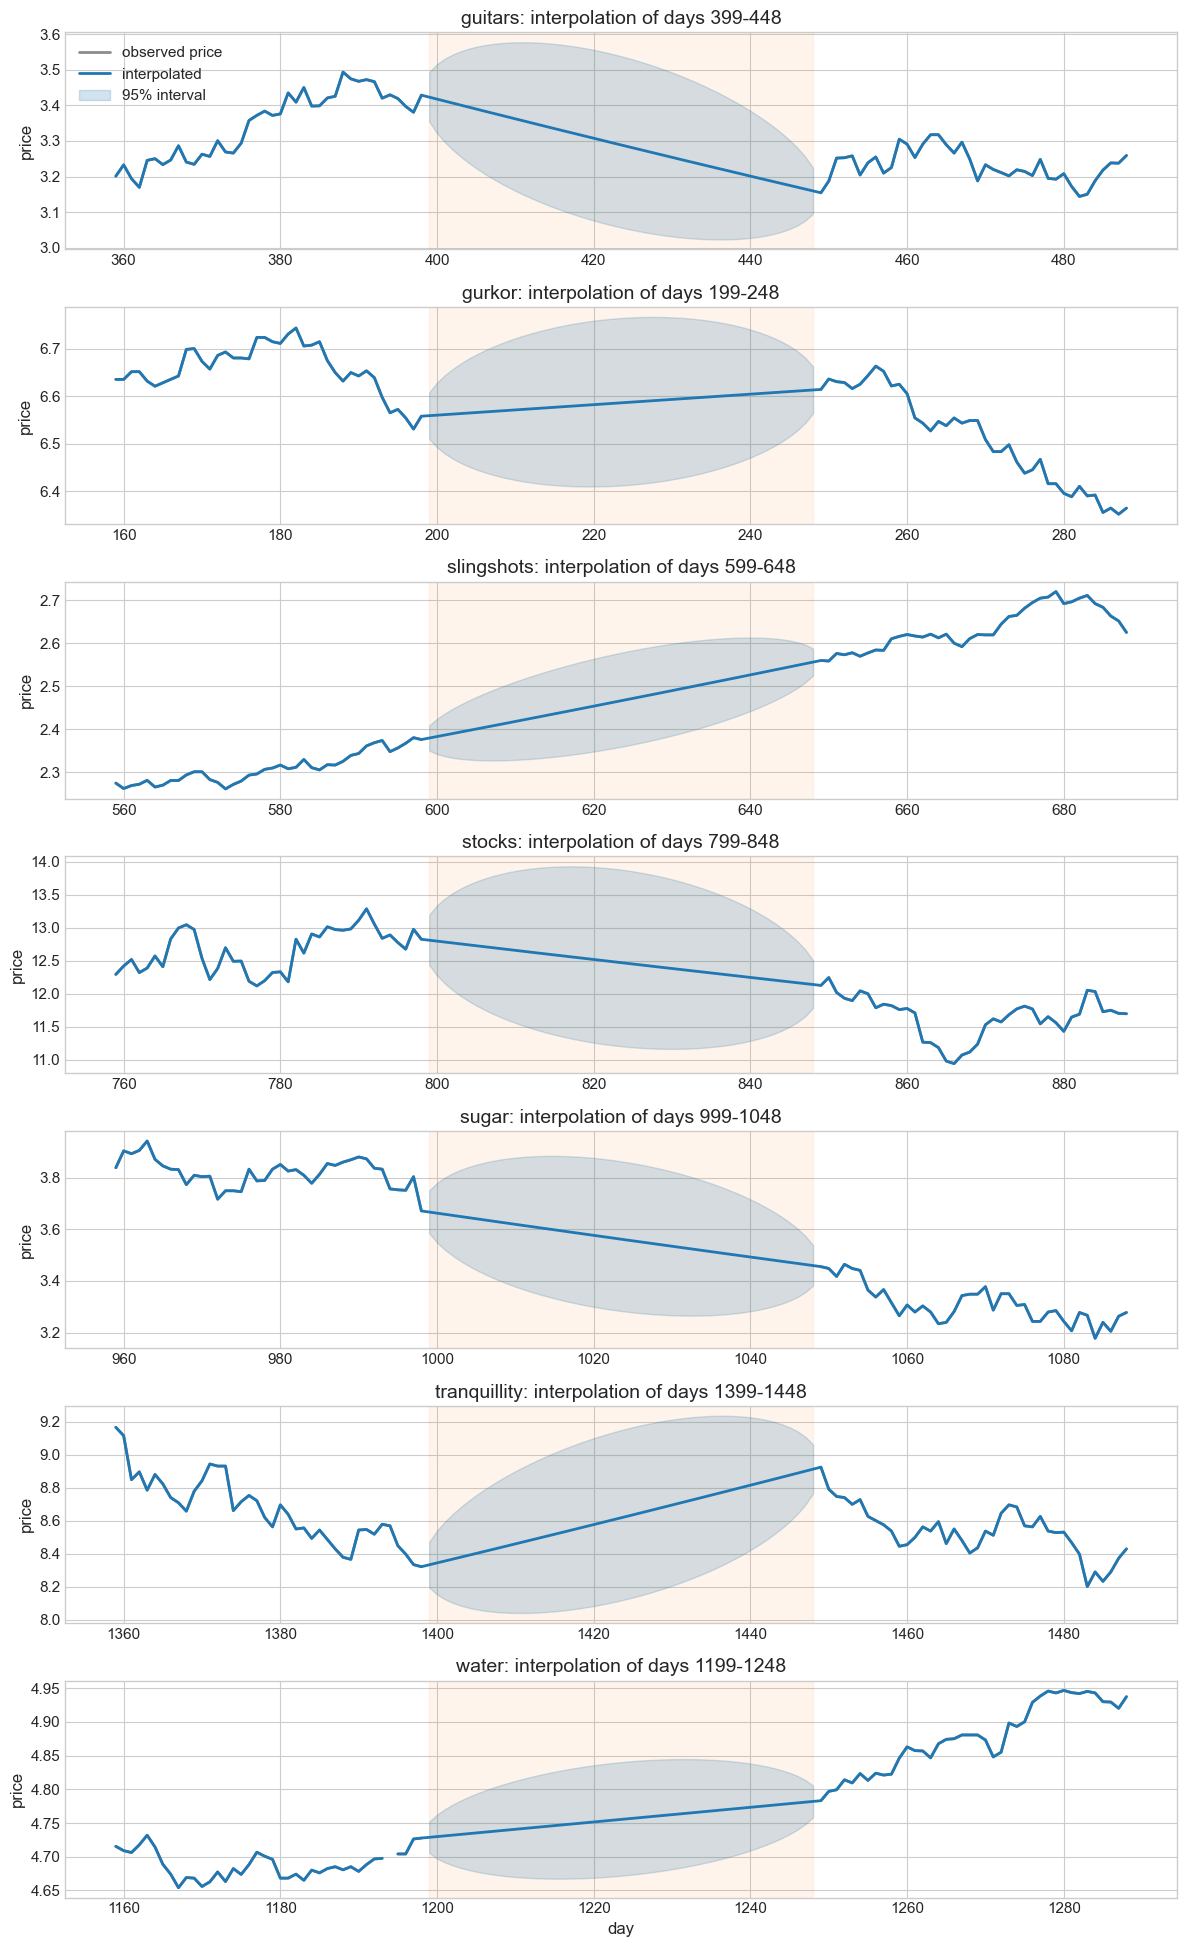

In [6]:
fig, axes = plt.subplots(len(internal_gaps), 1, figsize=(12, 2.8 * len(internal_gaps)), squeeze=False)

for row_idx, gap in enumerate(internal_gaps.itertuples(index=False)):
    ax = axes[row_idx, 0]
    left = max(int(prices.index.min()), gap.start - context_window)
    right = min(int(prices.index.max()), gap.end + context_window)
    window_index = range(left, right + 1)

    ax.plot(prices.loc[window_index, gap.series].index, prices.loc[window_index, gap.series], color="0.55", label="observed price")
    ax.plot(interpolated_prices.loc[window_index, gap.series].index, interpolated_prices.loc[window_index, gap.series], color="tab:blue", label="interpolated")
    ax.fill_between(
        range(gap.start, gap.end + 1),
        lower_95_prices.loc[gap.start : gap.end, gap.series].to_numpy(),
        upper_95_prices.loc[gap.start : gap.end, gap.series].to_numpy(),
        color="tab:blue",
        alpha=0.2,
        label="95% interval" if row_idx == 0 else None,
    )
    ax.axvspan(gap.start, gap.end, color="tab:orange", alpha=0.08)
    ax.set_title(f"{gap.series}: interpolation of days {gap.start}-{gap.end}")
    ax.set_ylabel("price")

axes[0, 0].legend(loc="upper left")
axes[-1, 0].set_xlabel("day")
plt.tight_layout()
plt.show()


## 5. Conclusions and expected performance

This gives a coherent starting solution for Task 2.

Main points:

- The method respects the lessons from Task 1 by interpolating on the log-price scale instead of the raw price scale.
- It uses only observations outside the missing block, so the evaluation avoids leakage from the hidden values themselves.
- The uncertainty widens toward the middle of the gap, which matches the logic of interpolation between two fixed endpoints.
- The pseudo-gap backtest provides an empirical check of both point accuracy and interval calibration.

At this stage, the method should be viewed as a strong univariate baseline. It is statistically sound, easy to explain, and already provides point estimates and uncertainty for every missing value. A possible next improvement would be to test whether the cross-series pairs from Task 1, such as `gurkor`–`water` and `guitars`–`slingshots`, can improve interpolation further through multivariate information.
